In [5]:
!pip install -q xgboost openpyxl scikit-learn matplotlib seaborn joblib

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from xgboost import XGBClassifier

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  10000 non-null  int64  
 1   age_yrs                     10000 non-null  int64  
 2   weight_kg                   10000 non-null  float64
 3   height_cm                   10000 non-null  float64
 4   bmi                         10000 non-null  float64
 5   blood_group                 10000 non-null  int64  
 6   blood_group_label           10000 non-null  object 
 7   pulse_rate_bpm              10000 non-null  int64  
 8   rr_breaths_per_min          10000 non-null  int64  
 9   hemoglobin_g_dl             10000 non-null  float64
 10  cycle_regularity            10000 non-null  int64  
 11  cycle_regularity_label      10000 non-null  object 
 12  period_duration_days        10000 non-null  int64  
 13  marriage_duration_yrs       1000

In [8]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

print("Uploaded file:", file_name)

Saving Final_Project_Dataset_10000plus.xlsx to Final_Project_Dataset_10000plus.xlsx
Uploaded file: Final_Project_Dataset_10000plus.xlsx


In [13]:
df = pd.read_excel(
    file_name,
    sheet_name="Final_Dataset"
)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (10000, 48)


In [15]:
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))


First 5 rows:


,patient_id,age_yrs,weight_kg,height_cm,bmi,blood_group,blood_group_label,pulse_rate_bpm,rr_breaths_per_min,hemoglobin_g_dl,...,regular_exercise,follicle_no_left,follicle_no_right,avg_follicle_size_left_mm,avg_follicle_size_right_mm,endometrium_mm,pcos,bmi_category,total_follicles,age_group
0,10001,38,56.0,155.0,23.31,15,O+,70,18,12.19,...,0,7,6,18.3,14.6,9.5,0,Normal,13,35-39
1,10002,26,59.0,152.6,25.34,13,B+,78,20,11.16,...,0,4,5,17.4,18.1,7.1,0,Overweight,9,25-29
2,10003,26,76.8,171.5,26.11,13,B+,77,19,10.88,...,0,13,11,15.4,10.0,4.1,1,Overweight,24,25-29
3,10004,29,71.8,162.3,27.26,17,AB+,73,15,12.87,...,1,9,2,16.2,15.9,9.8,0,Overweight,11,25-29
4,10005,29,60.8,156.5,24.82,14,B-,70,16,10.76,...,1,1,7,16.0,17.1,8.1,0,Normal,8,25-29



Column names:
['patient_id', 'age_yrs', 'weight_kg', 'height_cm', 'bmi', 'blood_group', 'blood_group_label', 'pulse_rate_bpm', 'rr_breaths_per_min', 'hemoglobin_g_dl', 'cycle_regularity', 'cycle_regularity_label', 'period_duration_days', 'marriage_duration_yrs', 'pregnant', 'num_abortions', 'beta_hcg_1_miu_ml', 'beta_hcg_2_miu_ml', 'fsh_miu_ml', 'lh_miu_ml', 'lh_fsh_ratio', 'amh_ng_ml', 'prl_ng_ml', 'vit_d3_ng_ml', 'progesterone_ng_ml', 'tsh_miu_l', 'rbs_mg_dl', 'waist_inch', 'hip_inch', 'waist_hip_ratio', 'bp_systolic_mmhg', 'bp_diastolic_mmhg', 'weight_gain', 'hair_growth', 'skin_darkening', 'hair_loss', 'pimples', 'fast_food', 'regular_exercise', 'follicle_no_left', 'follicle_no_right', 'avg_follicle_size_left_mm', 'avg_follicle_size_right_mm', 'endometrium_mm', 'pcos', 'bmi_category', 'total_follicles', 'age_group']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 48 columns):
 #   Column                      Non-

In [16]:
print("\nPCOS TARGET DISTRIBUTION:")
print(df["pcos"].value_counts())

print("\nPCOS TARGET PERCENTAGE:")
print(df["pcos"].value_counts(normalize=True) * 100)


PCOS TARGET DISTRIBUTION:
pcos
0    6700
1    3300
Name: count, dtype: int64

PCOS TARGET PERCENTAGE:
pcos
0    67.0
1    33.0
Name: proportion, dtype: float64


In [17]:
columns_to_remove = [
    "patient_id",
    "blood_group_label",
    "cycle_regularity_label",
    "bmi_category",
    "age_group",
    "pcos"
]

X = df.drop(columns=columns_to_remove)
y = df["pcos"]

In [18]:
print("\nData types before conversion:")

print(X.dtypes)


for column in X.columns:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )



Data types before conversion:
age_yrs                         int64
weight_kg                     float64
height_cm                     float64
bmi                           float64
blood_group                     int64
pulse_rate_bpm                  int64
rr_breaths_per_min              int64
hemoglobin_g_dl               float64
cycle_regularity                int64
period_duration_days            int64
marriage_duration_yrs         float64
pregnant                        int64
num_abortions                   int64
beta_hcg_1_miu_ml             float64
beta_hcg_2_miu_ml             float64
fsh_miu_ml                    float64
lh_miu_ml                     float64
lh_fsh_ratio                  float64
amh_ng_ml                     float64
prl_ng_ml                     float64
vit_d3_ng_ml                  float64
progesterone_ng_ml            float64
tsh_miu_l                     float64
rbs_mg_dl                     float64
waist_inch                    float64
hip_inch           

In [19]:
print("\nFinal feature data types:")

print(X.dtypes)

print("\nNumber of features:", X.shape[1])


Final feature data types:
age_yrs                         int64
weight_kg                     float64
height_cm                     float64
bmi                           float64
blood_group                     int64
pulse_rate_bpm                  int64
rr_breaths_per_min              int64
hemoglobin_g_dl               float64
cycle_regularity                int64
period_duration_days            int64
marriage_duration_yrs         float64
pregnant                        int64
num_abortions                   int64
beta_hcg_1_miu_ml             float64
beta_hcg_2_miu_ml             float64
fsh_miu_ml                    float64
lh_miu_ml                     float64
lh_fsh_ratio                  float64
amh_ng_ml                     float64
prl_ng_ml                     float64
vit_d3_ng_ml                  float64
progesterone_ng_ml            float64
tsh_miu_l                     float64
rbs_mg_dl                     float64
waist_inch                    float64
hip_inch               

In [20]:
imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("\nMissing values after imputation:")
print(X_imputed.isnull().sum().sum())


Missing values after imputation:
0


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (8000, 42)
Testing data: (2000, 42)


In [22]:
model = XGBClassifier(

    # Number of boosting trees
    n_estimators=500,

    # Maximum depth of each tree
    max_depth=5,

    # Learning rate
    learning_rate=0.03,

    # Percentage of rows used for each tree
    subsample=0.85,

    # Percentage of features used for each tree
    colsample_bytree=0.85,

    # Minimum child weight
    min_child_weight=1,

    gamma=0,

    # L1 regularization
    reg_alpha=0,

    # L2 regularization
    reg_lambda=1,

    # Binary classification
    objective="binary:logistic",

    # Evaluation metric
    eval_metric="logloss",

    # Reproducibility
    random_state=42,

    # Use all CPU cores
    n_jobs=-1
)

In [23]:
print("\nTraining XGBoost model...")

model.fit(
    X_train,
    y_train
)

print("\nModel training completed!")


Training XGBoost model...

Model training completed!


In [24]:
y_pred = model.predict(X_test)

# Predicted probability
y_probability = model.predict_proba(X_test)[:, 1]

In [25]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("\n==========================================")
print("          MODEL PERFORMANCE")
print("==========================================")

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("==========================================")




          MODEL PERFORMANCE
Accuracy  : 99.85%
Precision : 99.85%
Recall    : 99.70%
F1 Score  : 99.77%
ROC-AUC   : 1.0000


In [26]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No PCOS",
            "PCOS"
        ]
    )
)


Classification Report:
              precision    recall  f1-score   support

     No PCOS       1.00      1.00      1.00      1340
        PCOS       1.00      1.00      1.00       660

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



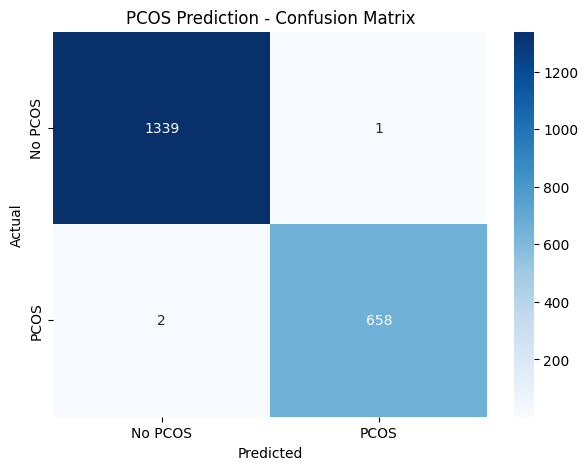

In [27]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No PCOS", "PCOS"],
    yticklabels=["No PCOS", "PCOS"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("PCOS Prediction - Confusion Matrix")

plt.show()

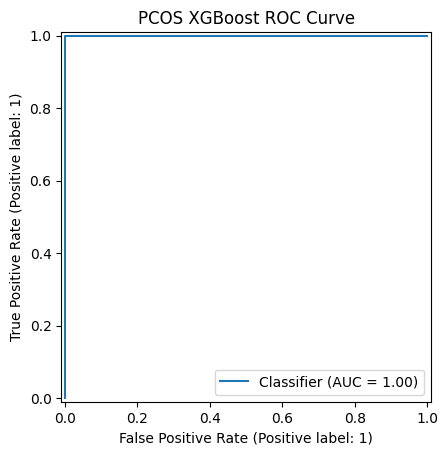

In [28]:
RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title("PCOS XGBoost ROC Curve")

plt.show()

In [29]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


print("\nTop 20 Important Features:")

display(
    feature_importance.head(20)
)




Top 20 Important Features:


,Feature,Importance
37,follicle_no_right,0.400829
41,total_follicles,0.324328
36,follicle_no_left,0.111201
38,avg_follicle_size_left_mm,0.046120
39,avg_follicle_size_right_mm,0.019125
23,rbs_mg_dl,0.017044
8,cycle_regularity,0.015010
18,amh_ng_ml,0.010773
16,lh_miu_ml,0.010229
17,lh_fsh_ratio,0.006959


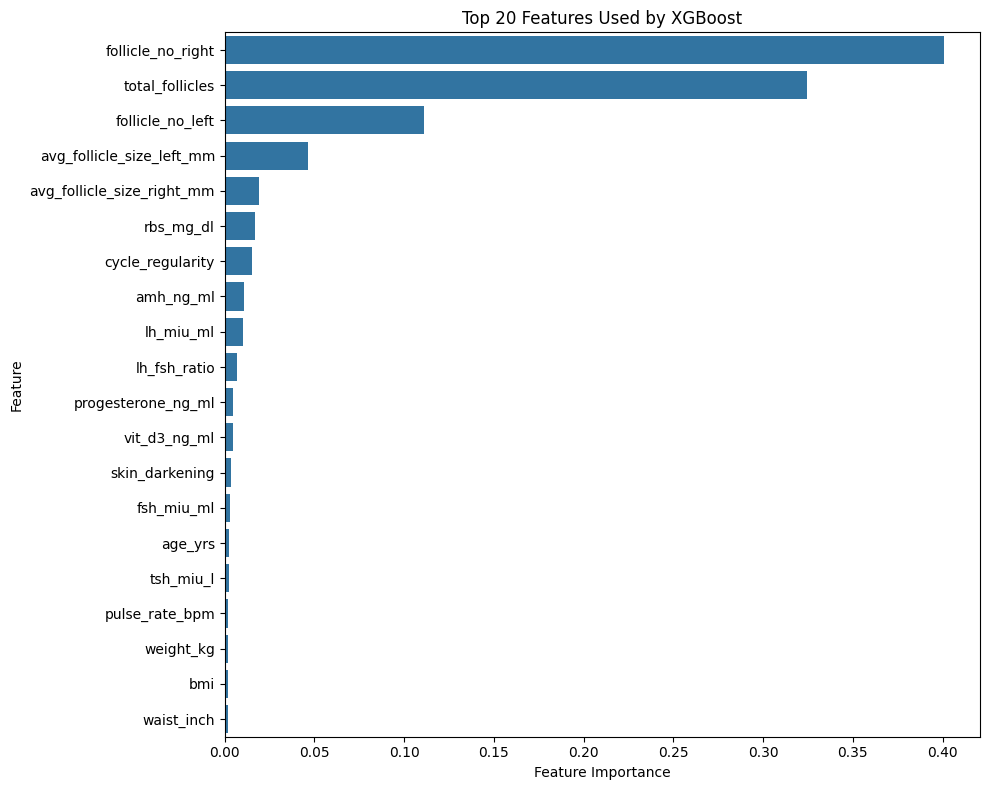

In [30]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Features Used by XGBoost")

plt.xlabel("Feature Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()


In [31]:
print("\nRunning 5-Fold Cross Validation...")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_imputed,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("\n5-Fold Accuracy Scores:")

for i, score in enumerate(cv_scores, 1):

    print(
        f"Fold {i}: {score * 100:.2f}%"
    )

print(
    f"\nMean CV Accuracy: {cv_scores.mean() * 100:.2f}%"
)

print(
    f"Standard Deviation: {cv_scores.std() * 100:.2f}%"
)


Running 5-Fold Cross Validation...

5-Fold Accuracy Scores:
Fold 1: 100.00%
Fold 2: 100.00%
Fold 3: 99.90%
Fold 4: 99.95%
Fold 5: 99.80%

Mean CV Accuracy: 99.93%
Standard Deviation: 0.07%


In [32]:
model.save_model(
    "pcos_xgboost_model.json"
)

print(
    "\nXGBoost model saved as: "
    "pcos_xgboost_model.json"
)


XGBoost model saved as: pcos_xgboost_model.json


In [33]:
joblib.dump(
    imputer,
    "pcos_imputer.pkl"
)

print(
    "Imputer saved as: pcos_imputer.pkl"
)


Imputer saved as: pcos_imputer.pkl


In [34]:
feature_list = X.columns.tolist()

joblib.dump(
    feature_list,
    "pcos_features.pkl"
)

print(
    "Feature list saved as: pcos_features.pkl"
)

Feature list saved as: pcos_features.pkl


In [35]:
feature_importance.to_csv(
    "pcos_feature_importance.csv",
    index=False
)

print(
    "Feature importance saved as: "
    "pcos_feature_importance.csv"
)

Feature importance saved as: pcos_feature_importance.csv


In [36]:
files.download(
    "pcos_xgboost_model.json"
)

files.download(
    "pcos_imputer.pkl"
)

files.download(
    "pcos_features.pkl"
)

files.download(
    "pcos_feature_importance.csv"
)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
sample = X_test.iloc[[0]]

actual_value = y_test.iloc[0]

prediction = model.predict(
    sample
)[0]

probability = model.predict_proba(
    sample
)[0][1]

print("\n==========================================")
print("          SAMPLE PREDICTION")
print("==========================================")

print(
    "Actual PCOS:",
    "PCOS" if actual_value == 1 else "No PCOS"
)

print(
    "Predicted:",
    "PCOS" if prediction == 1 else "No PCOS"
)

print(
    f"Model Risk Score: {probability * 100:.2f}%"
)

print("==========================================")


          SAMPLE PREDICTION
Actual PCOS: No PCOS
Predicted: No PCOS
Model Risk Score: 0.01%


In [38]:
def predict_pcos(user_data):

    """
    user_data must be a dictionary containing
    the same feature names used during training.
    """

    user_df = pd.DataFrame(
        [user_data]
    )

    # Ensure correct column order
    user_df = user_df[feature_list]

    # Convert to numeric
    user_df = user_df.apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Apply same imputer used during training
    user_df = pd.DataFrame(
        imputer.transform(user_df),
        columns=feature_list
    )

    # Prediction
    prediction = model.predict(
        user_df
    )[0]

    probability = model.predict_proba(
        user_df
    )[0][1]

    return {
        "prediction": int(prediction),
        "risk_score": float(probability)
    }


print("\n==========================================")
print("MODEL READY FOR WEB APP INTEGRATION")
print("==========================================")


MODEL READY FOR WEB APP INTEGRATION


In [39]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [40]:
import os

project_path = "/content/drive/MyDrive/PCOS_Flo_Project"
os.makedirs(project_path, exist_ok=True)

print("Folder ready:", project_path)

Folder ready: /content/drive/MyDrive/PCOS_Flo_Project


In [41]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)


In [42]:
model.save_model(
    "/content/drive/MyDrive/PCOS_Flo_Project/pcos_xgboost_model.json"
)

print("Model saved successfully!")

Model saved successfully!


In [43]:
import joblib

joblib.dump(
    imputer,
    "/content/drive/MyDrive/PCOS_Flo_Project/pcos_imputer.pkl"
)

joblib.dump(
    feature_list,
    "/content/drive/MyDrive/PCOS_Flo_Project/pcos_features.pkl"
)

feature_importance.to_csv(
    "/content/drive/MyDrive/PCOS_Flo_Project/pcos_feature_importance.csv",
    index=False
)

print("All model files saved!")

All model files saved!
